<a href="https://colab.research.google.com/github/triaanandafh/Mk_Data-Mining/blob/main/Untitled2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from sklearn import tree
from graphviz import Source
from sklearn.tree import export_graphviz
import os

PROJECT_ROOT_DIR = "."
CHAPTER_ID = "decision_trees"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

In [4]:
features = [[1,1,7], [1,0,12], [0,1,18], [0,1,35], [1,1,38], [1,0,50], [0,0,83]]
feature_names = ["Suka Cilok", "Suka Kopi", "Usia"]
targets = [0,0,1,1,1,0,0]
class_names = ["Tidak Suka BTS", "Suka BTS"]

In [5]:
classifier = tree.DecisionTreeClassifier()
classifier = classifier.fit(features, targets)

print(classifier.predict([[1,1,15]]))

[1]


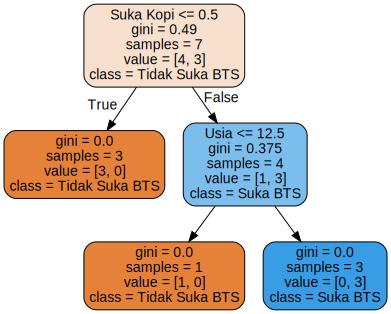

In [ ]:
export_graphviz(
    classifier,
    out_file=os.path.join(IMAGES_PATH, "bts.dot"),
    feature_names=feature_names,
    class_names=class_names,
    rounded=True,
    filled=True
)
Source.from_file(os.path.join(IMAGES_PATH, "bts.dot"))

In [8]:
# PERCOBAAN 2
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] # petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier()
tree_clf.fit(X, y)

DecisionTreeClassifier()

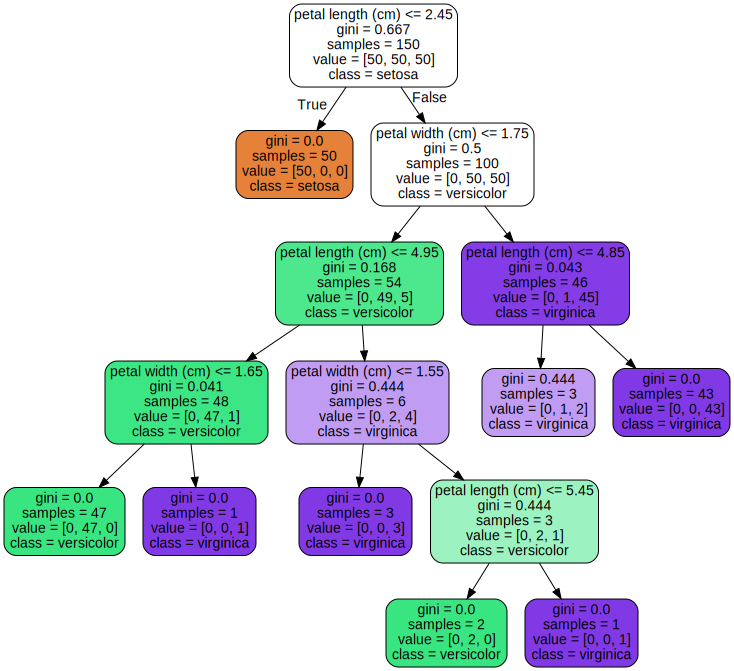

In [11]:
from graphviz import Source
from sklearn.tree import export_graphviz

export_graphviz(
    tree_clf,
    out_file=os.path.join(IMAGES_PATH, "iris_tree.dot"),
    feature_names=iris.feature_names[2:],
    class_names=iris.target_names,
    rounded=True,
    filled=True
)
Source.from_file(os.path.join(IMAGES_PATH, "iris_tree.dot"))

In [9]:
# PERCOBAAN 3
from sklearn.datasets import load_iris
iris = load_iris()

X =iris.data
y = iris.target

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.1)

from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier()

classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [18]:
predictions = classifier.predict(X_test)

from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, predictions))

1.0


In [23]:
# LATIHAN
from sklearn import tree
from sklearn.tree import export_graphviz
from graphviz import Source
import pandas as pd
import os

# 1. Load dataset yang sudah dibersihkan
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/Kuliah/Data-mining/Dataset SIB 2G.csv', sep=',')


# 2. Ambil kolom fitur (X) dan ubah menjadi list of lists (seperti di modul)
features = df[['Tinggi Badan (cm)', 'Berat Badan (kg)', 'Usia (tahun)']].values.tolist()
feature_names = ["Tinggi Badan (cm)", "Berat Badan (kg)", "Usia"]

# 3. Ambil kolom target (y) dan ubah menjadi angka: Laki-Laki = 0, Perempuan = 1
targets = df['Jenis Kelamin'].map({'Laki-Laki': 0, 'Perempuan': 1}).tolist()
class_names = ["Laki-Laki", "Perempuan"]



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
print(df.columns.tolist())

['Timestamp', 'Nama', 'Tempat Lahir', 'Tanggal Lahir', 'Jenis Kelamin', 'Tinggi Badan (cm)', 'Berat Badan (kg)', 'Kota Asal', 'Alamat Domisili Saat Ini', 'Jenis Kendaraan Utama', 'Pengeluaran BBM/Transport per Bulan (Rp)', 'IPK Semester Kemarin', 'Hobi', 'Alat Utama Mencatat Saat Kuliah', 'MBTI (kepribadian)', 'Waktu Produktif/Fokus', 'Rata - Rata Screen Time HP per Hari (jam)', 'Aplikasi Yang Paling Sering Dibuka di HP', 'Metode Pembayaran Favorit', 'Usia (tahun)', 'Jumlah Aplikasi di Hp', 'Jumlah Device yang Dimiliki']


['Motor']


/tmp/ipykernel_2143/3891111045.py:29: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Jenis Kelamin"] = le_gender.fit_transform(
/tmp/ipykernel_2143/3891111045.py:33: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Metode Pembayaran Favorit"] = le_payment.fit_transform(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


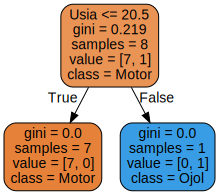

In [22]:
from sklearn import tree
from sklearn.tree import export_graphviz
from graphviz import Source
import pandas as pd
import os

# Menghapus data yang rusak
df = df.dropna(subset=["Nama"])

# Feature (X)
features = df[
    [
        "Usia (tahun)",
        "IPK Semester Kemarin",
        "Jumlah Device yang Dimiliki",
        "Jenis Kelamin",
        "Metode Pembayaran Favorit"
    ]]

# Target (Y)
targets = df["Jenis Kendaraan Utama"]

from sklearn.preprocessing import LabelEncoder

le_gender = LabelEncoder()
le_payment = LabelEncoder()

features["Jenis Kelamin"] = le_gender.fit_transform(
    features["Jenis Kelamin"]
)

features["Metode Pembayaran Favorit"] = le_payment.fit_transform(
    features["Metode Pembayaran Favorit"]
)

# Membuat model
classifier = tree.DecisionTreeClassifier()

# Training
classifier.fit(features, targets)

# Prediksi data baru
print(classifier.predict([[20, 3.8, 2, 1, 0]]))

# Visualisasi Tree
feature_names = [
    "Usia",
    "IPK",
    "Jumlah Device yang Dimiliki",
    "Jenis Kelamin",
    "Metode Pembayaran Favorit"
]

class_names = list(targets.unique())

export_graphviz(
    classifier,
    out_file="sib.dot",
    feature_names=feature_names,
    class_names=class_names,
    rounded=True,
    filled=True
)

Source.from_file("sib.dot")

In [25]:
df = df.dropna(subset=["Nama"])

features = df[["Usia (tahun)", "IPK Semester Kemarin", "Jumlah Device yang Dimiliki", "Jenis Kelamin", "Metode Pembayaran Favorit"]]
targets = df["Jenis Kendaraan Utama"]

# 3. Encoding Data Kategori (Sama seperti yang kamu lakukan)
le_gender = LabelEncoder()
le_payment = LabelEncoder()
features["Jenis Kelamin"] = le_gender.fit_transform(features["Jenis Kelamin"])
features["Metode Pembayaran Favorit"] = le_payment.fit_transform(features["Metode Pembayaran Favorit"])

classifier_knn = KNeighborsClassifier(n_neighbors=3, metric='euclidean')

# Training KNN
classifier_knn.fit(features, targets)

# Prediksi data baru menggunakan KNN
print("Hasil Prediksi KNN:")
print(classifier_knn.predict([[20, 3.8, 2, 1, 0]]))

Hasil Prediksi KNN:
['Motor']


/tmp/ipykernel_2143/2648721888.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Jenis Kelamin"] = le_gender.fit_transform(features["Jenis Kelamin"])
/tmp/ipykernel_2143/2648721888.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  features["Metode Pembayaran Favorit"] = le_payment.fit_transform(features["Metode Pembayaran Favorit"])
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted wi

In [26]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
import pandas as pd

# 1. Load dan bersihkan data
df = pd.read_csv('/content/drive/MyDrive/Kuliah/Data-mining/Dataset SIB 2G.csv', sep=',')
df = df.dropna(subset=["Nama"])

# 2. Siapkan Fitur dan Target
features = df[["Usia (tahun)", "IPK Semester Kemarin", "Jumlah Device yang Dimiliki", "Jenis Kelamin", "Metode Pembayaran Favorit"]].copy()
targets = df["Jenis Kendaraan Utama"]

# 3. Encoding Data Kategori
le_gender = LabelEncoder()
le_payment = LabelEncoder()
features["Jenis Kelamin"] = le_gender.fit_transform(features["Jenis Kelamin"])
features["Metode Pembayaran Favorit"] = le_payment.fit_transform(features["Metode Pembayaran Favorit"])

X = features.values
y = targets.values

# 4. Loop Perbandingan Jarak dan Nilai K
pilihan_k = [1, 3, 5]
pilihan_jarak = ['minkowski', 'euclidean']

print("=== HASIL PERBANDINGAN KNN PADA DATA SISWA ===\n")

for jarak in pilihan_jarak:
    print(f"Metode Jarak: {jarak.upper()}")
    print("-" * 35)
    for k in pilihan_k:
        knn = KNeighborsClassifier(n_neighbors=k, metric=jarak)
        knn.fit(X, y)
        y_pred = knn.predict(X)
        akurasi = accuracy_score(y, y_pred)
        print(f"  > Nilai K = {k} -> Akurasi: {akurasi * 100:.2f}%")
    print()

=== HASIL PERBANDINGAN KNN PADA DATA SISWA ===

Metode Jarak: MINKOWSKI
-----------------------------------
  > Nilai K = 1 -> Akurasi: 100.00%
  > Nilai K = 3 -> Akurasi: 87.50%
  > Nilai K = 5 -> Akurasi: 87.50%

Metode Jarak: EUCLIDEAN
-----------------------------------
  > Nilai K = 1 -> Akurasi: 100.00%
  > Nilai K = 3 -> Akurasi: 87.50%
  > Nilai K = 5 -> Akurasi: 87.50%

